# MULOC Parser
My attempt at replicating the matlab code to parse the muloc data from my custom version of the UWB tag+anchor firmware

In [25]:
import numpy as np
import cmath
import math
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import pathlib
import re
from itertools import batched


In [ ]:
#Constants


#this doesn't work with ipynb files!
#script_dir = pathlib.Path(__file__).parent.resolve()
input_data_path = "C:\\Users\\EdwardStuckey\\Documents\\GitHub\\MULoc_PIO\\matlab\\python_impl\\output_2026-09-11_20-33-29.log"

#number of anchors in the token ring arrangement
anchor_count = 2

#light speed
c = 299792458

#frequencies and wavelengths of each channel
channel_5_freq = 6489.6e6
lambda_channel_5 = c/channel_5_freq * 100

channel_9_freq = 7987.2e6
lambda_channel_9 = c/channel_9_freq * 100

#taken from the matlab script, it's the same between both DW1000 and DW3000
dw_time_resolution = 17.2/(2**40)

#4000 us between each anchor transmission
anchor_time = 4000e-6

#time for a token to travel around the ring
complete_loop_time = anchor_time * anchor_count




## Class definitions

Putting all the classes here I (think) I'll need to sort the data effectively

In [27]:

# A 0
# 1A,FFFFE5,3110,29,7,24917C2ED3,1,1,0
# FFFFF8,8,E8,2C,C,5CA253C84,0,64,1
# T
# FFFFF7,D,D62,30,B,526854F96,FFFFFFC0,1,0
# FFFFEC,FFFFF1,DEA,2A,F,CB56BEAB5,FFFFF42C,64,1


#a single telemetry piece from an anchor
class AnchorTelemetrySingle:

    def __init__(self) -> None:
        
        #self.cir_real: float = 0.0
        #self.cir_imaginary: float = 0.0

        self.cir: complex = 0 + 0j
        self.phase_correction: float = 0.0
        self.preamble_accumulation: float = 0.0
        self.max_growth_cir: float = 0.0
        self.rx_time: float = 0.0

        #the anchor this data came from
        self.anchor_id: int = 0


#a list of all the data above as it relates to a single anchor
#i.e. a single anchor maintains a collection of the above data gotten from the rest of the anchors
#a single row of anchors stuff
class AnchorInfoList:

    def __init__(self) -> None:
        self.packet_list: list[AnchorTelemetrySingle] = []

        #the anchor all this packet data was sent to (each one in the packet_list will have a different ID to this)
        self.rx_anchor_id: int = 0


#holds all the "rows" of anchor stuff
class LumpedAnchorInfoList:

    def __init__(self) -> None:

        #combined list of all anchors
        self.packet_list: list[AnchorInfoList] = []

        #the sequence in the greater chain this was part of (not sure how useful this is in the long run)
        self.sequence_number: int = 0

        #what frequency all the packets in this list were gotten at
        self.is_freq_5: bool = False





#A single piece of data gotten from the tag side of things as it overheard the anchor broadcast
#A single one of these IS a row
class TagTelemetrySingle:

    def __init__(self) -> None:
        self.cir: complex = 0 + 0j
        self.phase_correction: float = 0.0  #phase_cal
        self.preamble_accumulation: float = 0.0
        self.max_growth_cir: float = 0.0 #max_gcs
        self.rx_time: float = 0.0

        #the anchor this packet was heard from
        self.anchor_id: int = 0

        #the thing not included in the AnchroInfoPacket
        self.carrier_integrator: float = 0.0


#list of data calculated by the tag as it got the anchor data in
#holds all the rows of anchor stuff
#class TagTelemetryList:
#    def __init__(self) -> None:
#        self.packet_list: list[TagTelemetrySingle] = []


class TagTelemetryList:

    def __init__(self) -> None:

        #combined list of all tags
        self.packet_list: list[TagTelemetrySingle] = []

        #the sequence in the greater chain this was part of (not sure how useful this is in the long run)
        self.sequence_number: int = 0

        #what frequency all the packets in this list were gotten at
        self.is_freq_5: bool = False





## Loading code

parses the raw serial dump into the classes defined above

In [28]:
#from the robot, converts any hex string into a signed int with bit width
def hex_to_signed(hex_str, bit_width) -> int:
    #parse as normal unsigned integer
    val = int(hex_str, 16)
    
    #if the sign bit is set, subtract the maximum possible value range
    if val >= (1 << (bit_width - 1)):
        val -= (1 << bit_width)

    return val


#parse a complete list of anchor hex strings
def parse_anchor_hex(input_hex: list[str]) -> LumpedAnchorInfoList:
    #print(input_hex)

    all_anchors: LumpedAnchorInfoList = LumpedAnchorInfoList()

    for row in input_hex:

        if(row == ''):
            continue
        
        anchor_row: AnchorInfoList = AnchorInfoList()

        values = re.split(r',', row)

        #every entry from an anchor will have 7 values
        entry_count = int(len(values) / 7)
        for i in range(entry_count):
            index = i * 7

            cir_real = hex_to_signed(values[index + 0], 24)
            cir_imaginary = hex_to_signed(values[index + 1], 24)
            phase_correction = int(values[index + 2], 16)
            preamble_accumulation = int(values[index + 3], 16)
            max_growth_cir = int(values[index + 4], 16)
            rx_time = int(values[index + 5], 16)
            anchor_id = int(values[index + 6], 16)



            ats: AnchorTelemetrySingle = AnchorTelemetrySingle()
            ats.cir = complex(cir_real, cir_imaginary)
            ats.phase_correction = float(phase_correction)
            ats.preamble_accumulation = float(preamble_accumulation)
            ats.max_growth_cir = float(max_growth_cir)
            ats.rx_time = float(rx_time)
            ats.anchor_id = anchor_id
            anchor_row.packet_list.append(ats)

        all_anchors.packet_list.append(anchor_row)

        ...
    ...

    return all_anchors



def parse_tag_hex(input_hex: list[str]) -> TagTelemetryList:

    all_tags: TagTelemetryList = TagTelemetryList()

    for row in input_hex:

        if(row == ''):
            continue

        values = re.split(r',', row)


        #each entry will have 9 values
        index = 0        
        cir_real = hex_to_signed(values[index + 0], 24)
        cir_imaginary = hex_to_signed(values[index + 1], 24)
        phase_correction = int(values[index + 2], 16)
        preamble_accumulation = int(values[index + 3], 16)
        max_growth_cir = int(values[index + 4], 16)
        rx_time = int(values[index + 5], 16)
        carrier_integrator = hex_to_signed(values[index + 6], 32)
        #sequence_num = int(values[index + 7], 10) #don't need this
        anchor_id = int(values[index + 8], 16)

        ts: TagTelemetrySingle = TagTelemetrySingle()
        ts.cir = complex(cir_real, cir_imaginary)
        ts.phase_correction = float(phase_correction)
        ts.preamble_accumulation = float(preamble_accumulation)
        ts.max_growth_cir = float(max_growth_cir)
        ts.rx_time = float(rx_time)
        ts.anchor_id = anchor_id

        #the thing not included in the AnchroInfoPacket. It takes some extra conversion
        #this conversion is outlined on page 148 of the DW3000 user manual
        #we convert the carrier integrator into a frequency offset and then a clock offset in ppm
        carrier_integrator = -carrier_integrator * (998.4e6/2.0/1024.0/131072.0)
        ts.carrier_integrator = float(carrier_integrator)
        all_tags.packet_list.append(ts)
        ...

    return all_tags

    ...



def load_data(filename: str) -> tuple[list[LumpedAnchorInfoList], list[TagTelemetryList]]:

    file_p = open(filename)

    buffer = file_p.read()

    file_p.close()

    #split the input file by the `A #` pattern (by complete token round)
    parts = re.split(r'A ', buffer)
    
    # #skip the very first element if it's empty (occurs because file starts with the separator)
    # start_idx = 1 if parts[0] == '' else 0
    # chunks = []
    # for i in range(start_idx, len(parts) - 1, 2):
    #     # Combine the "A #" header with the text block following it
    #     combined_chunk = parts[i] + parts[i+1]
    #     chunks.append(combined_chunk.strip())

    anchor_object_list: list[LumpedAnchorInfoList] = []
    tag_object_list: list[TagTelemetryList] = []

    #iterate through all the rounds
    for part in parts:
        #further splitting
        if(part != ''):

            #true if the message was sent using channel 5
            is_ch5 = False
            if(part[0] == "1"):
                is_ch5 = True

            no_leading_f = part[2:] #remove the leading frequency number from the text
            anchors_tags = re.split(r'T\n', no_leading_f)

            anchors = re.split(r'\n', anchors_tags[0])
            tags = re.split(r'\n', anchors_tags[1])

            parsed_anchor_objs = parse_anchor_hex(anchors)
            parsed_tag_objs = parse_tag_hex(tags)

            parsed_anchor_objs.is_freq_5 = is_ch5
            parsed_tag_objs.is_freq_5 = is_ch5


            anchor_object_list.append(parsed_anchor_objs)
            tag_object_list.append(parsed_tag_objs)

            #print(len(parsed_anchor_objs.packet_list))
            #print(len(parsed_tag_objs.packet_list))


        ...

    

    return (anchor_object_list, tag_object_list)

    ...


#load the file into discrete anchor and tag entries for processing
(anchor_object_list, tag_object_list) = load_data(input_data_path)


print("Cell ran. Loaded List Lengths:")

print(len(anchor_object_list))
print(len(tag_object_list))



Cell ran. Loaded List Lengths:
180
180


In [ ]:
#quick and dirty tag data loader for sanity checking. I'm getting the wrong output with my own data.



#Re-defined constants
input_data_path = "C:\\Users\\EdwardStuckey\\Documents\\GitHub\\MULoc_PIO\\matlab\\sample_data\\location1_2_tag1.txt"

#number of anchors in the token ring arrangement
anchor_count = 4

#light speed
c = 299792458

#frequencies and wavelengths of each channel
channel_5_freq = 3484.0e6
lambda_channel_5 = c/channel_5_freq * 100

channel_9_freq = 4484.8e6
lambda_channel_9 = c/channel_9_freq * 100

#taken from the matlab script, it's the same between both DW1000 and DW3000
dw_time_resolution = 17.2/(2**40)

#this many seconds between each packet
anchor_time = 615.6464e-6

#time for a token to travel around the ring
complete_loop_time = anchor_time * anchor_count

def load_mlab_tag() -> list[TagTelemetryList]:
    ...







## Clock drift estimation

uhhh.... what do I say here?

In [47]:
#the CFO came from reading the carrier integrator value in the tag

#wraps angle between (-pi, pi]
def wrap_to_pi(phase_angle: float) -> float:
    return (phase_angle + math.pi) % (2 * math.pi) - math.pi
    ...


#carrier frequency offset coarse
def cfo_coarse(
        combined_cfo: float,
        cir_ch5: complex,
        cir_ch9: complex,
        last_cir_ch5: complex,
        last_cir_ch9: complex,
        frequency_ch5: float,
        frequency_ch9: float,
        loop_time: float
        ) -> float:

    #convert complex numbers into angles
    ch5_phase = cmath.phase(cir_ch5)
    ch9_phase = cmath.phase(cir_ch9)

    last_ch5_phase = cmath.phase(last_cir_ch5)
    last_ch9_phase = cmath.phase(last_cir_ch9)


    #find phase differences
    phase_diff_ch5 = wrap_to_pi(ch5_phase - last_ch5_phase)
    phase_diff_ch9 = wrap_to_pi(ch9_phase - last_ch9_phase)




    #a lot of this code is kinda blindly taken from the original matlab stuff
    #this replicates the second half of equation 12
    wrap_factor = 1/(frequency_ch9 - frequency_ch5)/loop_time*1e6

    #resolve ambiguity
    phase_diff = phase_diff_ch5 - phase_diff_ch9

    ambiguity_l = math.floor(combined_cfo / wrap_factor)

    #coarse grained clock drift
    c_temp = (phase_diff / 2 / math.pi + ambiguity_l) * wrap_factor

    #add or subtract the wrap factor to, y'know, wrap it
    #this (I believe) is the closest equivalent to the matlab implementation I could do, and I don't quite understand why it's done this way.
    if(c_temp - combined_cfo < wrap_factor * 0.5):
        c_temp += wrap_factor

    if(c_temp - combined_cfo > wrap_factor * 0.5):
        c_temp -= wrap_factor

    return c_temp

    ...

#only uses a single frequency instead of both
def cfo_fine(
        coarse_cfo: float,
        cir_ch: complex, #for phase angle
        last_cir_ch: complex, #for delta phase angle
        frequency: float,
        loop_time: float   
        ) -> float:


    ch_phase = cmath.phase(cir_ch)
    last_ch_phase = cmath.phase(last_cir_ch)

    wrap_factor = 1 / frequency / loop_time * 1e6

    phase_diff = wrap_to_pi(ch_phase - last_ch_phase)

    ambiguity_l = math.floor(coarse_cfo / wrap_factor)


    #fine grained clock drift
    c_temp = (phase_diff / 2 / math.pi + ambiguity_l) * wrap_factor

    #wrap it
    if(c_temp - coarse_cfo < wrap_factor * 0.5):
        c_temp += wrap_factor

    if(c_temp - coarse_cfo > wrap_factor * 0.5):
        c_temp -= wrap_factor


    return c_temp
    ...




#test data, used to collect outputs at various stages in the main iterator so we can plot them afterwards
all_cfo_raws: list[list[float]] = []
all_cfo_coarses: list[list[float]] = []
all_cfo_fines: list[list[float]] = []

#we need to keep track of the last values because some operations like CFO look at the difference between 2 of the same measurement
last_anchor_5: LumpedAnchorInfoList = LumpedAnchorInfoList()
last_tag_5: TagTelemetryList = TagTelemetryList()
last_anchor_9: LumpedAnchorInfoList = LumpedAnchorInfoList()
last_tag_9: TagTelemetryList = TagTelemetryList()

#turn our list of anchors and tags into ch5-ch9 pairs
#this is how our live application will see them, in single sets at a time, so that's how we need to process them
for (e, ((anchor_5, tag_5), (anchor_9, tag_9))) in enumerate(batched(zip(anchor_object_list, tag_object_list), 2)):

    #skip first entry, we need delta entries
    if(e == 0):
        last_anchor_5 = anchor_5
        last_tag_5 = tag_5
        last_anchor_9 = anchor_9
        last_tag_9 = tag_9
        continue

    cfo_raws: list[float] = []
    cfo_coarses: list[float] = []
    cfo_fines: list[float] = []

    #iterate through each tag's gotten anchor
    for i in range(0, len(tag_5.packet_list)):

        #for readability
        tag_5_v = tag_5.packet_list[i]
        tag_9_v = tag_9.packet_list[i]
        #delta values
        last_tag_5_v = last_tag_5.packet_list[i]
        last_tag_9_v = last_tag_9.packet_list[i]


        #convert into correct units (don't know what units these are...)
        cfo_ch5 = tag_5_v.carrier_integrator * (1e6 / channel_5_freq)
        cfo_ch9 = tag_9_v.carrier_integrator * (1e6 / channel_9_freq)

        #average them together
        cfo_average = (cfo_ch5 + cfo_ch9) * 0.5

        #todo: shifting window smoothing

        #find coarse carrier frequency offset
        coarse_output = cfo_coarse(
            cfo_average,
            tag_5_v.cir,
            tag_9_v.cir,
            last_tag_5_v.cir,
            last_tag_9_v.cir,
            channel_5_freq,
            channel_9_freq,
            complete_loop_time
            )
        

        #todo: shifting window smoothing (again)

        fine_output_ch5 = cfo_fine(coarse_output, tag_5_v.cir, last_tag_5_v.cir, channel_5_freq, complete_loop_time)
        fine_output_ch9 = cfo_fine(coarse_output, tag_9_v.cir, last_tag_9_v.cir, channel_9_freq, complete_loop_time)
        #average them
        fine_output = (fine_output_ch5 + fine_output_ch9) * 0.5


        #store for analysis
        #print(f"{cfo_average} | {coarse_output}")
        cfo_raws.append(cfo_average)
        cfo_coarses.append(coarse_output)
        cfo_fines.append(fine_output)

        ...

    #save data for graphing later
    all_cfo_raws.append(cfo_raws)
    all_cfo_coarses.append(cfo_coarses)
    all_cfo_fines.append(cfo_fines)



    #save for next readout
    last_anchor_5 = anchor_5
    last_tag_5 = tag_5
    last_anchor_9 = anchor_9
    last_tag_9 = tag_9

    ...




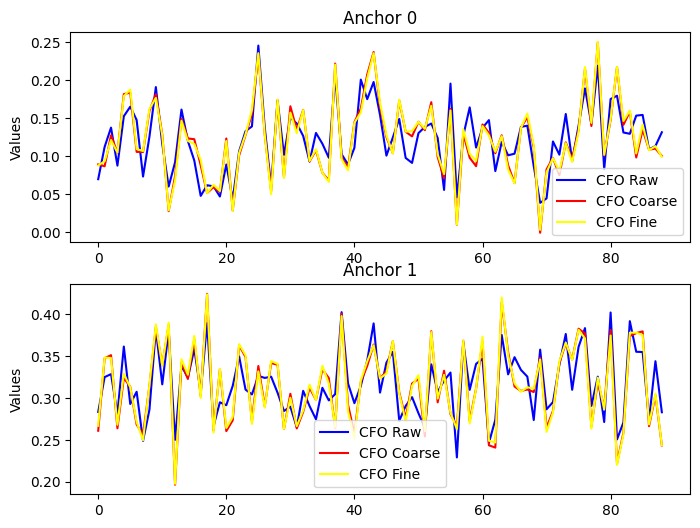

In [49]:
#display collected data



cfo_raws_0 = []
cfo_raws_1 = []
for i in all_cfo_raws:
    cfo_raws_0.append(i[0])
    cfo_raws_1.append(i[1])

cfo_coarses_0 = []
cfo_coarses_1 = []
for i in all_cfo_coarses:
    cfo_coarses_0.append(i[0])
    cfo_coarses_1.append(i[1])


cfo_fines_0 = []
cfo_fines_1 = []
for i in all_cfo_fines:
    cfo_fines_0.append(i[0])
    cfo_fines_1.append(i[1])


#print(all_cfo_coarses)

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].plot(cfo_raws_0, label='CFO Raw', color='blue')
axes[0].plot(cfo_coarses_0, label='CFO Coarse', color='red')
axes[0].plot(cfo_fines_0, label='CFO Fine', color='yellow')
axes[0].set_title('Anchor 0')
axes[0].set_ylabel('Values')
axes[0].legend()

axes[1].plot(cfo_raws_1, label='CFO Raw', color='blue')
axes[1].plot(cfo_coarses_1, label='CFO Coarse', color='red')
axes[1].plot(cfo_fines_1, label='CFO Fine', color='yellow')
axes[1].set_title('Anchor 1')
axes[1].set_xlabel('')
axes[1].set_ylabel('Values')
axes[1].legend()

